In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [15]:
# Create a State
class QuadState(TypedDict):
    a : int
    b : int
    c : int

    equation : str
    discriminant : float
    result : str

In [16]:
def show_equation(state : QuadState) -> QuadState:
    expression = f"{state['a']}x^2 + {state['b']}x + {state['c']}"

    return {'equation' : expression}

In [17]:
def calc_discriminant(state : QuadState) -> QuadState:
    disc = (state['b']**2)-(4*state['a']*state['c'])

    return {'discriminant' : disc}

In [18]:
def real_root(state : QuadState) -> QuadState:
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f"The roots are {root1} and {root2}"

    return {'result' : result}

In [19]:
def repeated_root(state : QuadState) -> QuadState:
    root = (-state["b"])/(2*state["a"])
    
    result = f"The only root is {root}"
    return {'result' : result}

In [20]:
def no_real_root(state : QuadState) -> QuadState:
    result = f"There are no real roots"

    return {'result' : result}

In [21]:
def routing_function(state: QuadState) -> Literal['real_root', 'repeated_root', 'no_real_root']:
    if state['discriminant'] > 0:
        return 'real_root'
    
    elif state['discriminant'] == 0:
        return 'repeated_root'
    
    else:
        return 'no_real_root'

In [22]:
# Create a Graph
graph = StateGraph(QuadState)

# Create a Node
graph.add_node('show_equation', show_equation)
graph.add_node('discriminant', calc_discriminant)
graph.add_node('real_root', real_root)
graph.add_node('repeated_root', repeated_root)
graph.add_node('no_real_root', no_real_root)


# Create edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'discriminant')
graph.add_conditional_edges('discriminant', routing_function)
graph.add_edge('real_root', END)
graph.add_edge('repeated_root', END)
graph.add_edge('no_real_root', END)


# Compile the graph
workflow = graph.compile()




In [26]:
initial_state = {'a' : 2, 'b': 4, 'c' : 2}

final_state = workflow.invoke(initial_state)

print(final_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x^2 + 4x + 2', 'discriminant': 0, 'result': 'The only root is -1.0'}


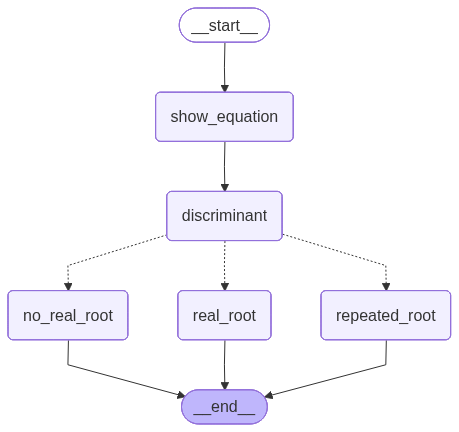

In [27]:
workflow